<center><h1><span style="color: green;">THỰC HÀNH BUỔI 12</span></h1></center>

In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


# Ví dụ 1:

## (a) Tự xây dựng các bước:

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from cvxopt import matrix, solvers

# Tạo dữ liệu
np.random.seed(10)
means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 100
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X = np.concatenate((X0.T, X1.T), axis=1)
y = np.concatenate((np.ones((1, N)), -1 * np.ones((1, N))), axis=1)

Phần hiển thị dữ liệu trên hình vẽ để có quan sát trực quan.


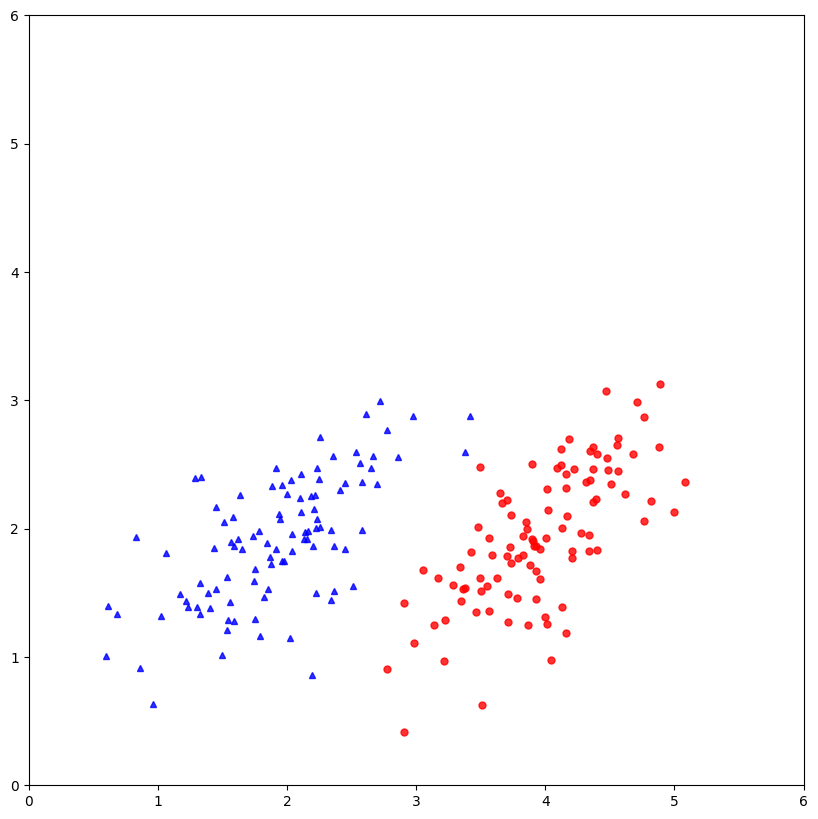

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
ani = plt.cla()
#plot points
ani = plt.plot(X0.T[0, :], X0.T[1, :], 'b^', markersize = 5, alpha = .8)
ani = plt.plot(X1.T[0, :], X1.T[1, :], 'ro', markersize = 5, alpha = .8)
ani = plt.axis([0 , 6, 0, 6])
plt.show()

###  **SVM bằng Lagrange**

In [17]:
#!pip install cvxopt
from cvxopt import matrix, solvers
V = np.concatenate((X0.T, -X1.T), axis=1)
P = matrix(V.T.dot(V))
q = matrix(-np.ones((2 * N, 1)))
G = matrix(-np.eye(2 * N))
h = matrix(np.zeros((2 * N, 1)))
A = matrix(y)
b = matrix(np.zeros((1, 1)))
solvers.options['show_progress'] = False
sol = solvers.qp(P, q, G, h, A, b)
l = np.array(sol['x'])
l = np.array(sol['x']) # lambda
print('lambda = ')
print(l.T)

lambda = 
[[6.43830372e-10 4.72988123e-10 6.96301261e-10 5.79332567e-10
  5.85394978e-10 5.88997480e-10 4.89184241e-10 5.67664894e-10
  4.93959294e-10 8.11159682e-10 7.35998382e+01 5.84752419e-10
  6.33981206e-10 5.70452608e-10 5.33265241e-10 6.21992621e-10
  6.30547706e-10 6.42898737e-10 6.23309373e-10 7.19237900e-10
  6.37162151e-10 5.62750933e-10 5.43352984e-10 5.34317125e-10
  6.12473191e-10 5.54489279e-10 5.15178968e-10 6.11949009e-10
  7.11337568e-10 6.01640553e-10 6.16174828e-10 7.08582794e-10
  6.28907978e-10 9.47883549e-10 5.60470453e-10 5.73546044e-10
  5.40206464e-10 5.84839273e-10 4.52413498e-10 5.71685467e-10
  6.69868839e-10 4.47707836e-10 3.99526097e-10 5.50379371e-10
  8.79639914e-10 6.28698683e-10 6.73190935e-10 6.03403938e-10
  5.36740042e-10 1.22567795e-09 8.50987129e-10 4.93131967e-10
  6.05327442e-10 5.32588255e-10 7.14356409e-10 6.36992251e-10
  7.63436068e-10 5.89166800e-10 5.36104164e-10 9.45023473e-10
  6.67949637e-10 6.12129203e-10 6.46493582e-10 6.24525894e-1

In [18]:
epsilon = 1e-6
S = np.where(l > epsilon)[0]
VS = V[:, S]
XS = X[:, S]
yS = y[:, S]
lS = l[S]
w_dual = VS.dot(lS)
w0_dual = np.mean(yS.T - w_dual.T.dot(XS))

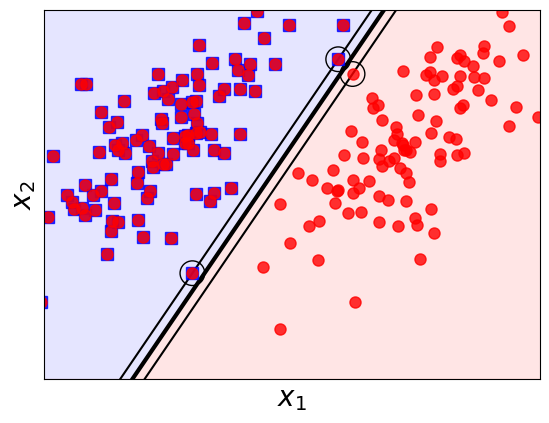

In [32]:
from matplotlib.backends.backend_pdf import PdfPages
fig, ax = plt.subplots()
x1 = np.arange(-10, 10, 0.1)
y1 = -w_dual[0, 0]/w_dual[1, 0]*x1 - w0_dual/w_dual[1, 0]
y2 = -w_dual[0, 0]/w_dual[1, 0]*x1 - (w0_dual-1)/w_dual[1, 0]
y3 = -w_dual[0, 0]/w_dual[1, 0]*x1 - (w0_dual+1)/w_dual[1, 0]
plt.plot(x1, y1, 'k', linewidth = 3)
plt.plot(x1, y2, 'k')
plt.plot(x1, y3, 'k')
y4 = 10*x1
plt.plot(x1, y1, 'k')
plt.fill_between(x1, y1, color='red', alpha=0.1)
plt.fill_between(x1, y1, y4, color = 'blue', alpha = 0.1)
plt.plot(X0[:, 0], X0[:, 1], 'bs', markersize = 8, alpha = .8)
plt.plot(X1[:, 0], X1[:, 1], 'ro', markersize = 8, alpha = .8)
plt.axis('equal')
plt.ylim(0, 3)
plt.xlim(2, 4)
# hide tikcs
cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
# add circles around support vectors
for m in S:
  circle = plt.Circle((X[0, m], X[1, m] ), 0.1, color='k', fill = False)
  ax.add_artist(circle)
plt.xlabel('$x_1$', fontsize = 20)
plt.ylabel('$x_2$', fontsize = 20)
# plt.savefig('svm4.png', bbox_inches='tight', dpi = 300)
# pdf.savefig()
plt.show()

## (b) Sử dụng thư viện:

In [25]:
y1 = y.reshape((2 * N,))
X1 = X.T
clf = SVC(kernel='linear', C=1e5)
clf.fit(X1, y1)
w_sklearn = clf.coef_.reshape(-1, 1)
w0_sklearn = clf.intercept_[0]

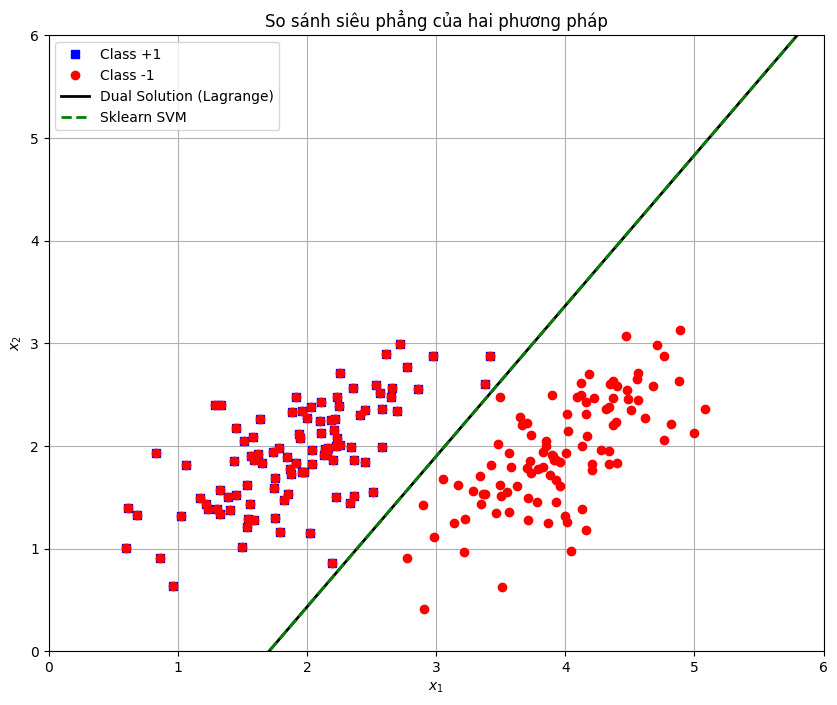

In [26]:
x1 = np.linspace(0, 6, 200)
y_dual = -(w_dual[0, 0] / w_dual[1, 0]) * x1 - w0_dual / w_dual[1, 0]
y_sklearn = -(w_sklearn[0, 0] / w_sklearn[1, 0]) * x1 - w0_sklearn / w_sklearn[1, 0]

plt.figure(figsize=(10, 8))
plt.plot(X0[:, 0], X0[:, 1], 'bs', label='Class +1')
plt.plot(X1[:, 0], X1[:, 1], 'ro', label='Class -1')
plt.plot(x1, y_dual, 'k-', linewidth=2, label='Dual Solution (Lagrange)')
plt.plot(x1, y_sklearn, 'g--', linewidth=2, label='Sklearn SVM')
plt.title('So sánh siêu phẳng của hai phương pháp')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)
plt.axis([0, 6, 0, 6])
plt.show()

# Bài Thực Hành 1: Dự đoán lại tập dữ liệu ban đầu bằng vector trọng số w

Chúng ta sử dụng bộ trọng số $ w $ và $ w_0 $ đã tính được từ phương pháp Hard Margin SVM để phân lớp lại toàn bộ dữ liệu ban đầu.

Sau đó:
- Tính toán độ chính xác (Accuracy)
- Hiển thị ma trận nhầm lẫn (Confusion Matrix)

## Tạo lại dữ liệu và huấn luyện SVM bằng Lagrange

In [44]:
import numpy as np
from cvxopt import matrix, solvers

# Tạo dữ liệu
np.random.seed(10)
means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 100
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X = np.concatenate((X0.T, X1.T), axis=1)
y = np.concatenate((np.ones((1, N)), -1 * np.ones((1, N))), axis=1)

# Hard Margin SVM bằng Lagrange đối ngẫu
V = np.concatenate((X0.T, -X1.T), axis=1)
P = matrix(V.T.dot(V))
q = matrix(-np.ones((2 * N, 1)))
G = matrix(-np.eye(2 * N))
h = matrix(np.zeros((2 * N, 1)))
A = matrix(y)
b = matrix(np.zeros((1, 1)))
solvers.options['show_progress'] = False
sol = solvers.qp(P, q, G, h, A, b)
l = np.array(sol['x'])

# Lọc lambda và tính w, w0
epsilon = 1e-6
S = np.where(l > epsilon)[0]
VS = V[:, S]
XS = X[:, S]
yS = y[:, S]
lS = l[S]
w = VS.dot(lS)
w0 = np.mean(yS.T - w.T.dot(XS))


Dự đoán và đánh giá

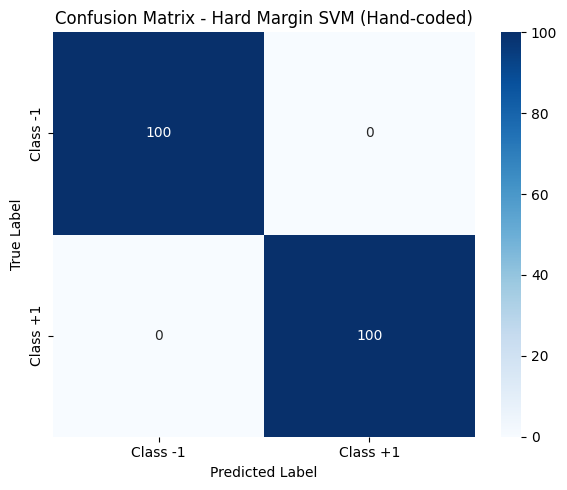

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Dự đoán
X_data = X  # Dữ liệu ban đầu
y_true = y.flatten()
y_pred = np.sign(w.T.dot(X_data) + w0).flatten()

# Tính độ chính xác và confusion matrix
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class -1', 'Class +1'],
            yticklabels=['Class -1', 'Class +1'])
plt.title('Confusion Matrix - Hard Margin SVM (Hand-coded)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


# Bài tập thực hành 2:

In [39]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Tải dữ liệu ung thư vú từ sklearn
cancer_data = datasets.load_breast_cancer()
X = cancer_data.data
y = cancer_data.target

# Mã hóa lại nhãn: 0 = Malignant (ác tính) => -1, 1 = Benign (lành tính) => 1
y = np.where(y == 0, -1, 1)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chia dữ liệu huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=109)

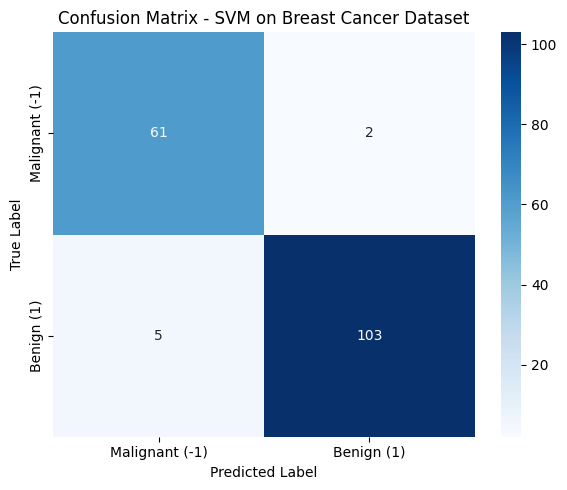

In [43]:
# Huấn luyện mô hình SVM với hard margin (C lớn)
svm_cancer = SVC(kernel='linear', C=1e6)
svm_cancer.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred_cancer = svm_cancer.predict(X_test)
acc_cancer = accuracy_score(y_test, y_pred_cancer)
cm_cancer = confusion_matrix(y_test, y_pred_cancer)

# Trực quan hóa ma trận nhầm lẫn cho bài tập 2
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cancer, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (-1)', 'Benign (1)'],
            yticklabels=['Malignant (-1)', 'Benign (1)'])
plt.title('Confusion Matrix - SVM on Breast Cancer Dataset')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Ví dụ 2: Phân loại Sonar với các mức độ "margin" khác nhau

Trong ví dụ này, chúng ta áp dụng SVM để phân loại dữ liệu sóng âm Sonar (Mine vs Rock) từ file `sonar.all-data.csv`.  
Mục tiêu:
1. So sánh mô hình với:
   - (a) Hard margin SVM (`C ≥ 10^5`)
   - (b) Soft margin SVM (`C = 0.5`, `C = 5`)
2. Đánh giá bằng:
   - Accuracy (Độ chính xác)
   - Precision (Độ chính xác của lớp "Mine")
   - Recall (Khả năng phát hiện đúng "Mine")

In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Đọc dữ liệu
df = pd.read_csv('/content/drive/MyDrive/Classroom/MachineLearning/Lab12/sonar.all-data.csv', header=None)

# Tách thuộc tính và nhãn
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Mã hóa nhãn: 'M' -> 1 (Mine), 'R' -> -1 (Rock)
le = LabelEncoder()
y = le.fit_transform(y)
y = np.where(y == 0, -1, 1)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**Hàm đánh giá**

In [52]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score

def evaluate_svm(C_value):
    model = SVC(kernel='linear', C=C_value)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)

    return acc, prec, rec


## TH1: Sử dụng với $C >= 10^5$ ($C = 10^6$)

Với C rất lớn, mô hình cố gắng phân tách hoàn hảo hai lớp có thể dẫn tới overfitting nếu dữ liệu có nhiễu.

In [53]:
acc_hard, prec_hard, rec_hard = evaluate_svm(1e6)
print(f"[Hard Margin] Accuracy: {acc_hard:.4f}, Precision: {prec_hard:.4f}, Recall: {rec_hard:.4f}")

[Hard Margin] Accuracy: 0.8095, Precision: 0.7667, Recall: 0.8214


## TH2: Đánh giá với C = 0.5 và C = 5

In [54]:
acc_soft_05, prec_soft_05, rec_soft_05 = evaluate_svm(0.5)
acc_soft_5, prec_soft_5, rec_soft_5 = evaluate_svm(5)

print(f"[Soft Margin C=0.5] Accuracy: {acc_soft_05:.4f}, Precision: {prec_soft_05:.4f}, Recall: {rec_soft_05:.4f}")
print(f"[Soft Margin C=5.0] Accuracy: {acc_soft_5:.4f}, Precision: {prec_soft_5:.4f}, Recall: {rec_soft_5:.4f}")

[Soft Margin C=0.5] Accuracy: 0.7460, Precision: 0.7308, Recall: 0.6786
[Soft Margin C=5.0] Accuracy: 0.7937, Precision: 0.7586, Recall: 0.7857


## Nhận xét kết quả theo từng độ đo

| Trường hợp       | Accuracy | Precision (Mine) | Recall (Mine) |
|------------------|----------|------------------|----------------|
| C = 10⁶           | 0.8095   | 0.7667           | 0.8214         |
| C = 0.5           | 0.7460   | 0.7308           | 0.6786         |
| C = 5.0           | 0.7937   | 0.7586           | 0.7857         |

### Accuracy:
- Cao nhất ở C = 10⁶ do mô hình cố gắng phân lớp tối đa.
- C = 0.5 cho độ chính xác thấp nhất, chứng tỏ khi nới lỏng margin quá mức sẽ làm mô hình kém phân biệt.

### Precision (Mine):
- C = 10⁶ và C = 5 đều có precision khá cao (trên 0.75), tức là ít dự đoán nhầm Rock thành Mine.
- Với C = 0.5, precision giảm nhẹ khiến mô hình dễ nhầm lẫn hơn.

### Recall (Mine):
- C = 10⁶ đạt recall cao nhất (0.8214) khiến mô hình nhận diện tốt các trường hợp thực sự là "Mine".
- C = 0.5 có recall thấp nhất khiến bỏ sót nhiều mìn thực sự.

### Tổng kết:
- C = 10⁶ (Hard Margin): phân loại tốt nhưng có thể overfit nếu dữ liệu nhiều nhiễu.
- C = 0.5: phù hợp khi chấp nhận margin lớn hơn, tuy nhiên giảm hiệu quả phát hiện "Mine".
- C = 5: là lựa chọn cân bằng, vẫn giữ precision và recall ổn định.

=> Nếu mục tiêu ưu tiên phát hiện đúng mìn (Recall cao), thì nên chọn C lớn (>= 5).